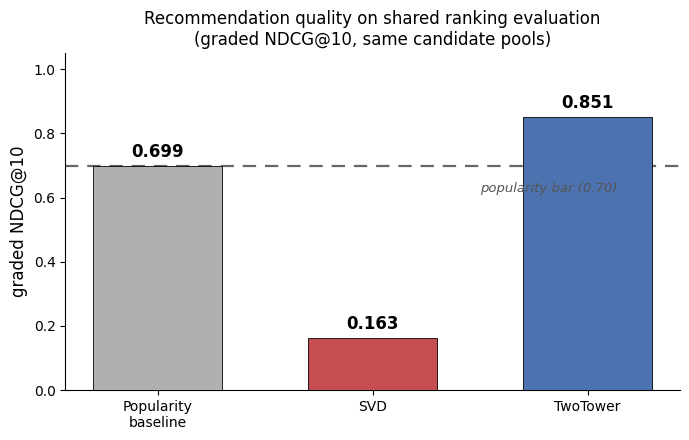

Saved: fig1_main_ndcg_comparison.png


In [2]:
import matplotlib.pyplot as plt

# === Figure 1: Main result — graded NDCG@10 across the three models ===
models = ["Popularity\nbaseline", "SVD", "TwoTower"]
ndcg   = [0.6992, 0.1628, 0.8508]
colors = ["#B0B0B0", "#C44E52", "#4C72B0"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(models, ndcg, color=colors, width=0.6, edgecolor="black", linewidth=0.6, zorder=3)

# value labels on top of each bar
for bar, v in zip(bars, ndcg):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f"{v:.3f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold", zorder=4)

ax.set_ylabel("graded NDCG@10", fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title("Recommendation quality on shared ranking evaluation\n(graded NDCG@10, same candidate pools)",
             fontsize=12)

# popularity reference line — darker dashed, full width, under the bars
ax.axhline(0.6992, color="#555555", linestyle=(0, (6, 4)), linewidth=1.6, alpha=0.9, zorder=1)

# label the line in the GAP between SVD and TwoTower (below the line, clear of all value labels)
ax.text(1.5, 0.6992 - 0.05, "popularity bar (0.70)",
        color="#555555", fontsize=9.5, ha="left", va="top", style="italic", zorder=4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
plt.tight_layout()

plt.savefig("fig1_main_ndcg_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig1_main_ndcg_comparison.png")

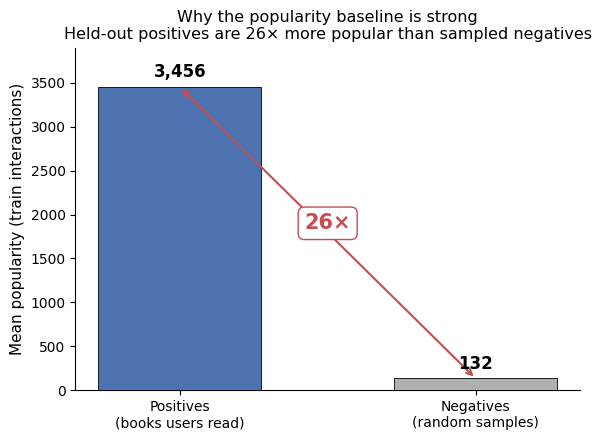

Saved: figA_popularity_bias.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

# === Finding A: popularity bias — positives are far more popular than negatives ===
# From twotower.ipynb: positives mean pop 3455.9 (median 757); negatives 131.9 (median 36); ratio 26.2x
groups = ["Positives\n(books users read)", "Negatives\n(random samples)"]
mean_pop = [3455.9, 131.9]
colors = ["#4C72B0", "#B0B0B0"]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(groups, mean_pop, color=colors, width=0.55, edgecolor="black", linewidth=0.6, zorder=3)

for bar, v in zip(bars, mean_pop):
    ax.text(bar.get_x() + bar.get_width()/2, v + 60, f"{v:,.0f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold", zorder=4)

ax.set_ylabel("Mean popularity (train interactions)", fontsize=11)
ax.set_ylim(0, 3900)
ax.set_title("Why the popularity baseline is strong\nHeld-out positives are 26× more popular than sampled negatives",
             fontsize=11.5)

# annotate the 26x ratio with an arrow between the bars
ax.annotate("", xy=(0, 3455.9), xytext=(1, 131.9),
            arrowprops=dict(arrowstyle="<->", color="#C44E52", lw=1.5))
ax.text(0.5, 1900, "26×", ha="center", va="center", fontsize=15, fontweight="bold",
        color="#C44E52", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#C44E52"))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("figA_popularity_bias.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figA_popularity_bias.png")

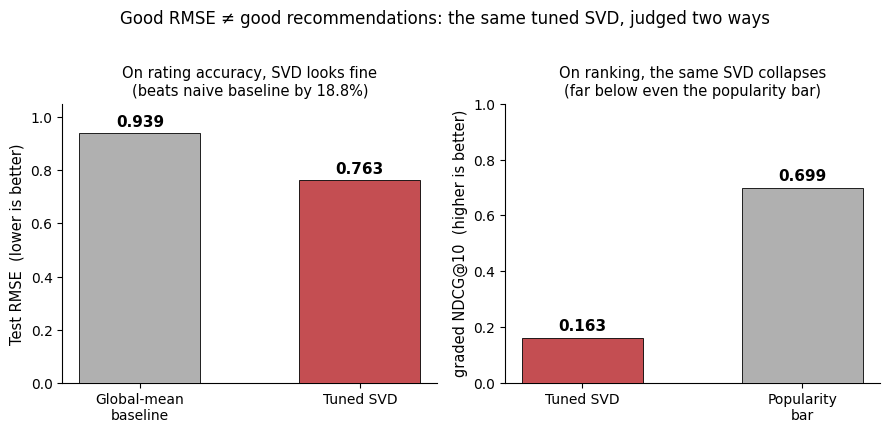

Saved: figB_rmse_ndcg_divergence.png


In [4]:
import matplotlib.pyplot as plt

# === Finding B: RMSE-NDCG divergence — the SAME tuned SVD, two metrics tell opposite stories ===
# Show each metric as SVD's position relative to its own reference, NOT a 3-model comparison (that's Fig 1).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.2))

# --- Left: RMSE (lower=better). Tuned SVD vs naive baseline — SVD looks decent ---
b1 = ax1.bar(["Global-mean\nbaseline", "Tuned SVD"], [0.9388, 0.7627],
             color=["#B0B0B0", "#C44E52"], width=0.55, edgecolor="black", linewidth=0.6, zorder=3)
for bar, v in zip(b1, [0.9388, 0.7627]):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.015, f"{v:.3f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_ylabel("Test RMSE  (lower is better)", fontsize=10.5)
ax1.set_ylim(0, 1.05)
ax1.set_title("On rating accuracy, SVD looks fine\n(beats naive baseline by 18.8%)", fontsize=10.5)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.set_axisbelow(True)

# --- Right: NDCG (higher=better). Tuned SVD vs the popularity bar it must clear — SVD falls short ---
b2 = ax2.bar(["Tuned SVD", "Popularity\nbar"], [0.1628, 0.6992],
             color=["#C44E52", "#B0B0B0"], width=0.55, edgecolor="black", linewidth=0.6, zorder=3)
for bar, v in zip(b2, [0.1628, 0.6992]):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.015, f"{v:.3f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax2.set_ylabel("graded NDCG@10  (higher is better)", fontsize=10.5)
ax2.set_ylim(0, 1.0)
ax2.set_title("On ranking, the same SVD collapses\n(far below even the popularity bar)", fontsize=10.5)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)
ax2.set_axisbelow(True)

fig.suptitle("Good RMSE ≠ good recommendations: the same tuned SVD, judged two ways",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figB_rmse_ndcg_divergence.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figB_rmse_ndcg_divergence.png")

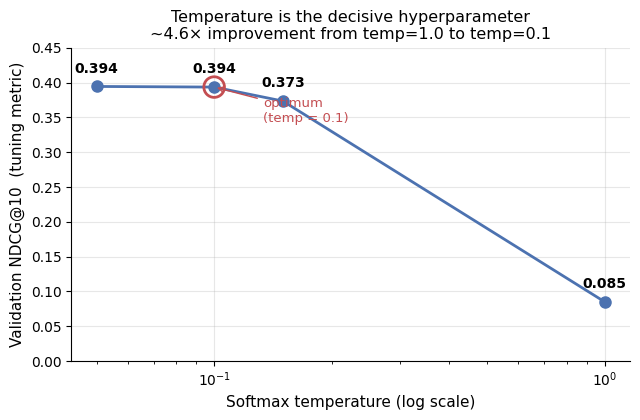

Saved: figS_temperature_sweep.png


In [5]:
import matplotlib.pyplot as plt

# === Supplementary: temperature sweep (the key tuning finding) ===
# From implementation notes §3.1 — LibRecommender per-epoch binary val NDCG@10 (2000-user subsample,
# used for model SELECTION; NOT the final graded NDCG of 0.85). embed=32, lr=0.001 fixed; only temp varies.
temps     = [0.05, 0.1, 0.15, 1.0]
val_ndcg  = [0.3944, 0.3935, 0.3734, 0.0852]

# sort by temperature for a clean left-to-right curve
pairs = sorted(zip(temps, val_ndcg))
temps_s  = [t for t, _ in pairs]
ndcg_s   = [n for _, n in pairs]

fig, ax = plt.subplots(figsize=(6.5, 4.3))
ax.plot(temps_s, ndcg_s, marker="o", markersize=8, linewidth=2,
        color="#4C72B0", zorder=3)

# annotate each point
for t, n in zip(temps_s, ndcg_s):
    ax.annotate(f"{n:.3f}", (t, n), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=10, fontweight="bold")

# highlight the optimum at 0.1
ax.scatter([0.1], [0.3935], s=220, facecolors="none", edgecolors="#C44E52",
           linewidths=2, zorder=4)
ax.annotate("optimum\n(temp = 0.1)", (0.1, 0.3935), textcoords="offset points",
            xytext=(35, -25), fontsize=9.5, color="#C44E52",
            arrowprops=dict(arrowstyle="->", color="#C44E52"))

ax.set_xscale("log")   # log scale so 0.05–1.0 spreads out readably
ax.set_xlabel("Softmax temperature (log scale)", fontsize=11)
ax.set_ylabel("Validation NDCG@10  (tuning metric)", fontsize=11)
ax.set_ylim(0, 0.45)
ax.set_title("Temperature is the decisive hyperparameter\n~4.6× improvement from temp=1.0 to temp=0.1",
             fontsize=11.5)
ax.grid(True, alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figS_temperature_sweep.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figS_temperature_sweep.png")

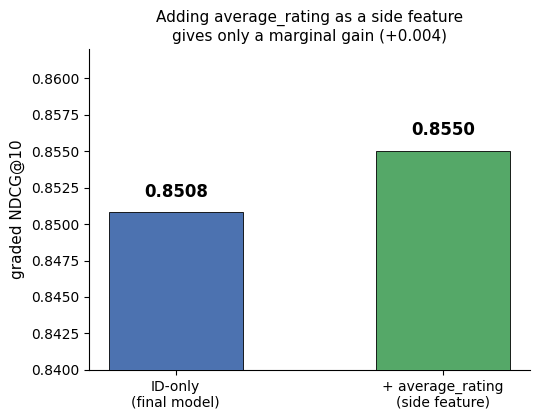

Saved: figS_side_feature.png


In [6]:
import matplotlib.pyplot as plt

# === Supplementary: side-feature ablation (ID-only vs + average_rating) ===
# From implementation notes §5.1 — final graded NDCG@10 (58,787 users). Adding average_rating
# as a side feature changes performance only marginally.
configs = ["ID-only\n(final model)", "+ average_rating\n(side feature)"]
ndcg    = [0.8508, 0.8550]
colors  = ["#4C72B0", "#55A868"]

fig, ax = plt.subplots(figsize=(5.5, 4.3))
bars = ax.bar(configs, ndcg, color=colors, width=0.5, edgecolor="black", linewidth=0.6, zorder=3)
for bar, v in zip(bars, ndcg):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.0008, f"{v:.4f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("graded NDCG@10", fontsize=11)
ax.set_ylim(0.84, 0.862)   # zoomed in so the small +0.004 gap is visible
ax.set_title("Adding average_rating as a side feature\ngives only a marginal gain (+0.004)", fontsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("figS_side_feature.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figS_side_feature.png")

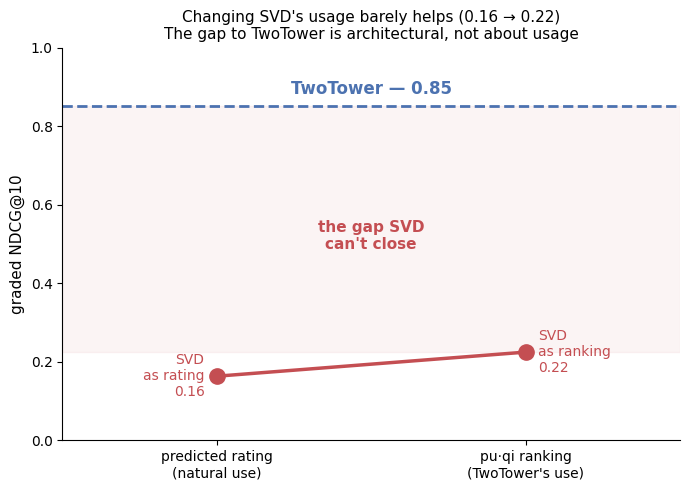

Saved: figC_slope.png


In [7]:
import matplotlib.pyplot as plt

# === Finding 3 (slope chart): SVD barely moves under its best usage; TwoTower is on another level ===
fig, ax = plt.subplots(figsize=(7, 5))

# SVD: rating -> ranking (two usages of the SAME model) — nearly flat line
ax.plot([0, 1], [0.1628, 0.2242], marker="o", markersize=11, linewidth=2.5,
        color="#C44E52", zorder=3)
ax.text(-0.04, 0.1628, "SVD\nas rating\n0.16", ha="right", va="center", fontsize=10, color="#C44E52")
ax.text(1.04, 0.2242, "SVD\nas ranking\n0.22", ha="left", va="center", fontsize=10, color="#C44E52")

# TwoTower reference line — way above, dashed
ax.axhline(0.8508, color="#4C72B0", linestyle="--", linewidth=2, zorder=2)
ax.text(0.5, 0.8508+0.02, "TwoTower — 0.85", ha="center", va="bottom",
        fontsize=12, fontweight="bold", color="#4C72B0")

# shaded "gap" band between SVD's best and TwoTower
ax.axhspan(0.2242, 0.8508, alpha=0.06, color="#C44E52", zorder=1)
ax.text(0.5, 0.52, "the gap SVD\ncan't close", ha="center", va="center",
        fontsize=11, fontweight="bold", color="#C44E52")

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1.0)
ax.set_xticks([0, 1])
ax.set_xticklabels(["predicted rating\n(natural use)", "pu·qi ranking\n(TwoTower's use)"], fontsize=10)
ax.set_ylabel("graded NDCG@10", fontsize=11)
ax.set_title("Changing SVD's usage barely helps (0.16 → 0.22)\nThe gap to TwoTower is architectural, not about usage", fontsize=11)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("figC_slope.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figC_slope.png")